# Hom-PGD: Convergence Comparison on a Star Set

This tutorial compares three inequality-only methods on one nonconvex star-constrained instance: projected gradient descent (PGD), radial dual (RD), and Hom-PGD. All methods receive the same decision-space starting point, reference objective, metric definitions, iteration budget, and saved-record workflow.

**Learning goals.** You will: 

1. specify a fair comparison through the shared benchmark API;
2. read objective and violation curves from the saved records;
3. compare total progress by iteration and elapsed time; and
4. compare outer per-iteration time with standard-deviation error bars.

## 1. Explicit comparison contract

The star problem is nonconvex, so IPOPT is an explicit multi-start numerical reference. FW is intentionally not included: its linear minimization oracle is defined for the polytope toy, not for this star-domain benchmark.

In [1]:
from __future__ import annotations

from pathlib import Path

WORKING_DIR = Path.cwd().resolve()
REPO_ROOT = WORKING_DIR if (WORKING_DIR / 'src' / 'homopt').is_dir() else WORKING_DIR.parents[1]
if not (REPO_ROOT / 'src' / 'homopt').is_dir():
    raise RuntimeError('Launch from the repository root or execute this notebook from tutorials/hom_pgd.')

TUTORIAL_CONFIG = {
    'seed': 2031,
    'device': 'cpu',
    'dtype': 'float32',
    'problem_type': 'star',
    'alpha': 0.35,
    'num_star': 5,
    'algorithms': ['PGD', 'RD', 'Hom-PGD'],
    'max_iterations': 300,
    'max_running_time': 60.0,
    'learning_rate': 3e-2,
    'stepsize_rule': 'adaptive',
    'lr_decay': 0.995,
    'min_lr': 1e-6,
    'common_config': {
        'initial_point_mode': 'gauge_center',
        'convergence_threshold': 1e-8,
    },
    'algorithm_config': {
        'PGD': {
            'learning_rate': 3e-2,
            'projection_max_iterations': 5,
            'projection_inner_iterations': 20,
        },
        'RD': {'learning_rate': 3e-2},
        'Hom-PGD': {'hom_p_norm': 2, 'learning_rate': 3e-2, 'momentum': 0.0},
    },
    'reference_solver': 'ipopt',
    'reference_label': 'IPOPT',
    'reference_ipopt_num_starts': 8,
    'method_labels': {'PGD': 'PGD', 'RD': 'RD', 'Hom-PGD': 'Hom-PGD'},
    'run_dir': REPO_ROOT / 'results' / 'tutorials' / 'hom_pgd' / '04_hom_pgd_convergence',
    'figure_dir': REPO_ROOT / 'results' / 'figs' / 'tutorials' / 'hom_pgd' / '04_hom_pgd_convergence',
}
# Keep each displayed panel at the same physical size in Jupyter and PDF output.
TUTORIAL_FIGURE_STYLE = {
    'panel_width': 5.6,
    'panel_height': 5.0,
    'single_panel': (5.6, 5.0),
    'two_panel': (11.2, 5.0),
}
TUTORIAL_CONFIG


{'seed': 2031,
 'device': 'cpu',
 'dtype': 'float32',
 'problem_type': 'star',
 'alpha': 0.35,
 'num_star': 5,
 'algorithms': ['PGD', 'RD', 'Hom-PGD'],
 'max_iterations': 300,
 'max_running_time': 60.0,
 'learning_rate': 0.03,
 'stepsize_rule': 'adaptive',
 'lr_decay': 0.995,
 'min_lr': 1e-06,
 'common_config': {'initial_point_mode': 'gauge_center',
  'convergence_threshold': 1e-08},
 'algorithm_config': {'PGD': {'learning_rate': 0.03,
   'projection_max_iterations': 5,
   'projection_inner_iterations': 20},
  'RD': {'learning_rate': 0.03},
  'Hom-PGD': {'hom_p_norm': 2, 'learning_rate': 0.03, 'momentum': 0.0}},
 'reference_solver': 'ipopt',
 'reference_label': 'IPOPT',
 'reference_ipopt_num_starts': 8,
 'method_labels': {'PGD': 'PGD', 'RD': 'RD', 'Hom-PGD': 'Hom-PGD'},
 'run_dir': PosixPath('/Users/lem/Projects/HomOPT/results/tutorials/hom_pgd/04_hom_pgd_convergence'),
 'figure_dir': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence')}

## 2. Run one shared instance

The benchmark constructs the problem once, computes its IPOPT reference once, resolves one shared initial point, and then runs each selected algorithm. The returned records are also stored under `run_dir/artifacts/records/` for later visualization-only use.

In [2]:
import numpy as np

from homopt.experiments.hom_pgd import poly_star_benchmark
from homopt.viz import apply_paper_style_rcparams, build_convex_2d_traces

apply_paper_style_rcparams()
payload, run_context = poly_star_benchmark(
    algorithms=TUTORIAL_CONFIG['algorithms'],
    common_config=TUTORIAL_CONFIG['common_config'],
    algorithm_config=TUTORIAL_CONFIG['algorithm_config'],
    alpha=TUTORIAL_CONFIG['alpha'],
    num_star=TUTORIAL_CONFIG['num_star'],
    problem_type=TUTORIAL_CONFIG['problem_type'],
    max_iterations=TUTORIAL_CONFIG['max_iterations'],
    max_running_time=TUTORIAL_CONFIG['max_running_time'],
    learning_rate=TUTORIAL_CONFIG['learning_rate'],
    stepsize_rule=TUTORIAL_CONFIG['stepsize_rule'],
    lr_decay=TUTORIAL_CONFIG['lr_decay'],
    min_lr=TUTORIAL_CONFIG['min_lr'],
    seed=TUTORIAL_CONFIG['seed'],
    output_dir=TUTORIAL_CONFIG['run_dir'],
    device=TUTORIAL_CONFIG['device'],
    dtype=TUTORIAL_CONFIG['dtype'],
    visualize=False,
    reference_solver=TUTORIAL_CONFIG['reference_solver'],
    reference_label=TUTORIAL_CONFIG['reference_label'],
    reference_ipopt_num_starts=TUTORIAL_CONFIG['reference_ipopt_num_starts'],
    return_context=True,
)
problem = run_context['problem']
reference = run_context['reference']
records = run_context['records']
summaries = run_context['summaries']
traces = build_convex_2d_traces(problem, records, TUTORIAL_CONFIG['algorithms'])

{
    'shared_initial_point': np.asarray(run_context['initial_point']).reshape(2),
    'reference_objective': float(reference['objective']),
    'reference_status': reference['status'],
    'saved_record_algorithms': list(records),
}


Running PGD


Running RD
Running Hom-PGD


{'shared_initial_point': array([0., 0.], dtype=float32),
 'reference_objective': 0.11649224907443691,
 'reference_status': 'optimal',
 'saved_record_algorithms': ['PGD', 'RD', 'Hom-PGD']}

## 3. Final metrics from the same records

The row values below are summaries derived immediately after each algorithm completes. `objective_gap_to_ipopt` is the final objective minus the IPOPT reference objective; it is a numerical comparison metric, not an optimality certificate for the nonconvex problem.

In [3]:
comparison_rows = []
for method in TUTORIAL_CONFIG['algorithms']:
    summary = summaries[method]
    comparison_rows.append({
        'method': TUTORIAL_CONFIG['method_labels'][method],
        'final_objective': float(summary['final_objective']),
        'objective_gap_to_ipopt': float(summary['final_objective'] - reference['objective']),
        'final_violation': float(summary['final_violation']),
        'recorded_iterates': int(traces[method]['objective'].size),
        'total_recorded_iter_time_s': float(traces[method]['time'][-1]),
    })
comparison_rows


[{'method': 'PGD',
  'final_objective': 0.14469903707504272,
  'objective_gap_to_ipopt': 0.028206788000605817,
  'final_violation': 0.0006192326545715332,
  'recorded_iterates': 301,
  'total_recorded_iter_time_s': 1.887045077572111},
 {'method': 'RD',
  'final_objective': 0.17318971455097198,
  'objective_gap_to_ipopt': 0.05669746547653508,
  'final_violation': 0.0,
  'recorded_iterates': 301,
  'total_recorded_iter_time_s': 0.06250572204589844},
 {'method': 'Hom-PGD',
  'final_objective': 0.14482757449150085,
  'objective_gap_to_ipopt': 0.028335325417063947,
  'final_violation': 0.0,
  'recorded_iterates': 150,
  'total_recorded_iter_time_s': 0.018787418375723064}]

## 4. Objective and feasibility convergence

Each call writes iteration-linear, iteration-log, time-linear, and time-log versions of the same curve. There are no equality-convergence plots because this benchmark has only inequality constraints.

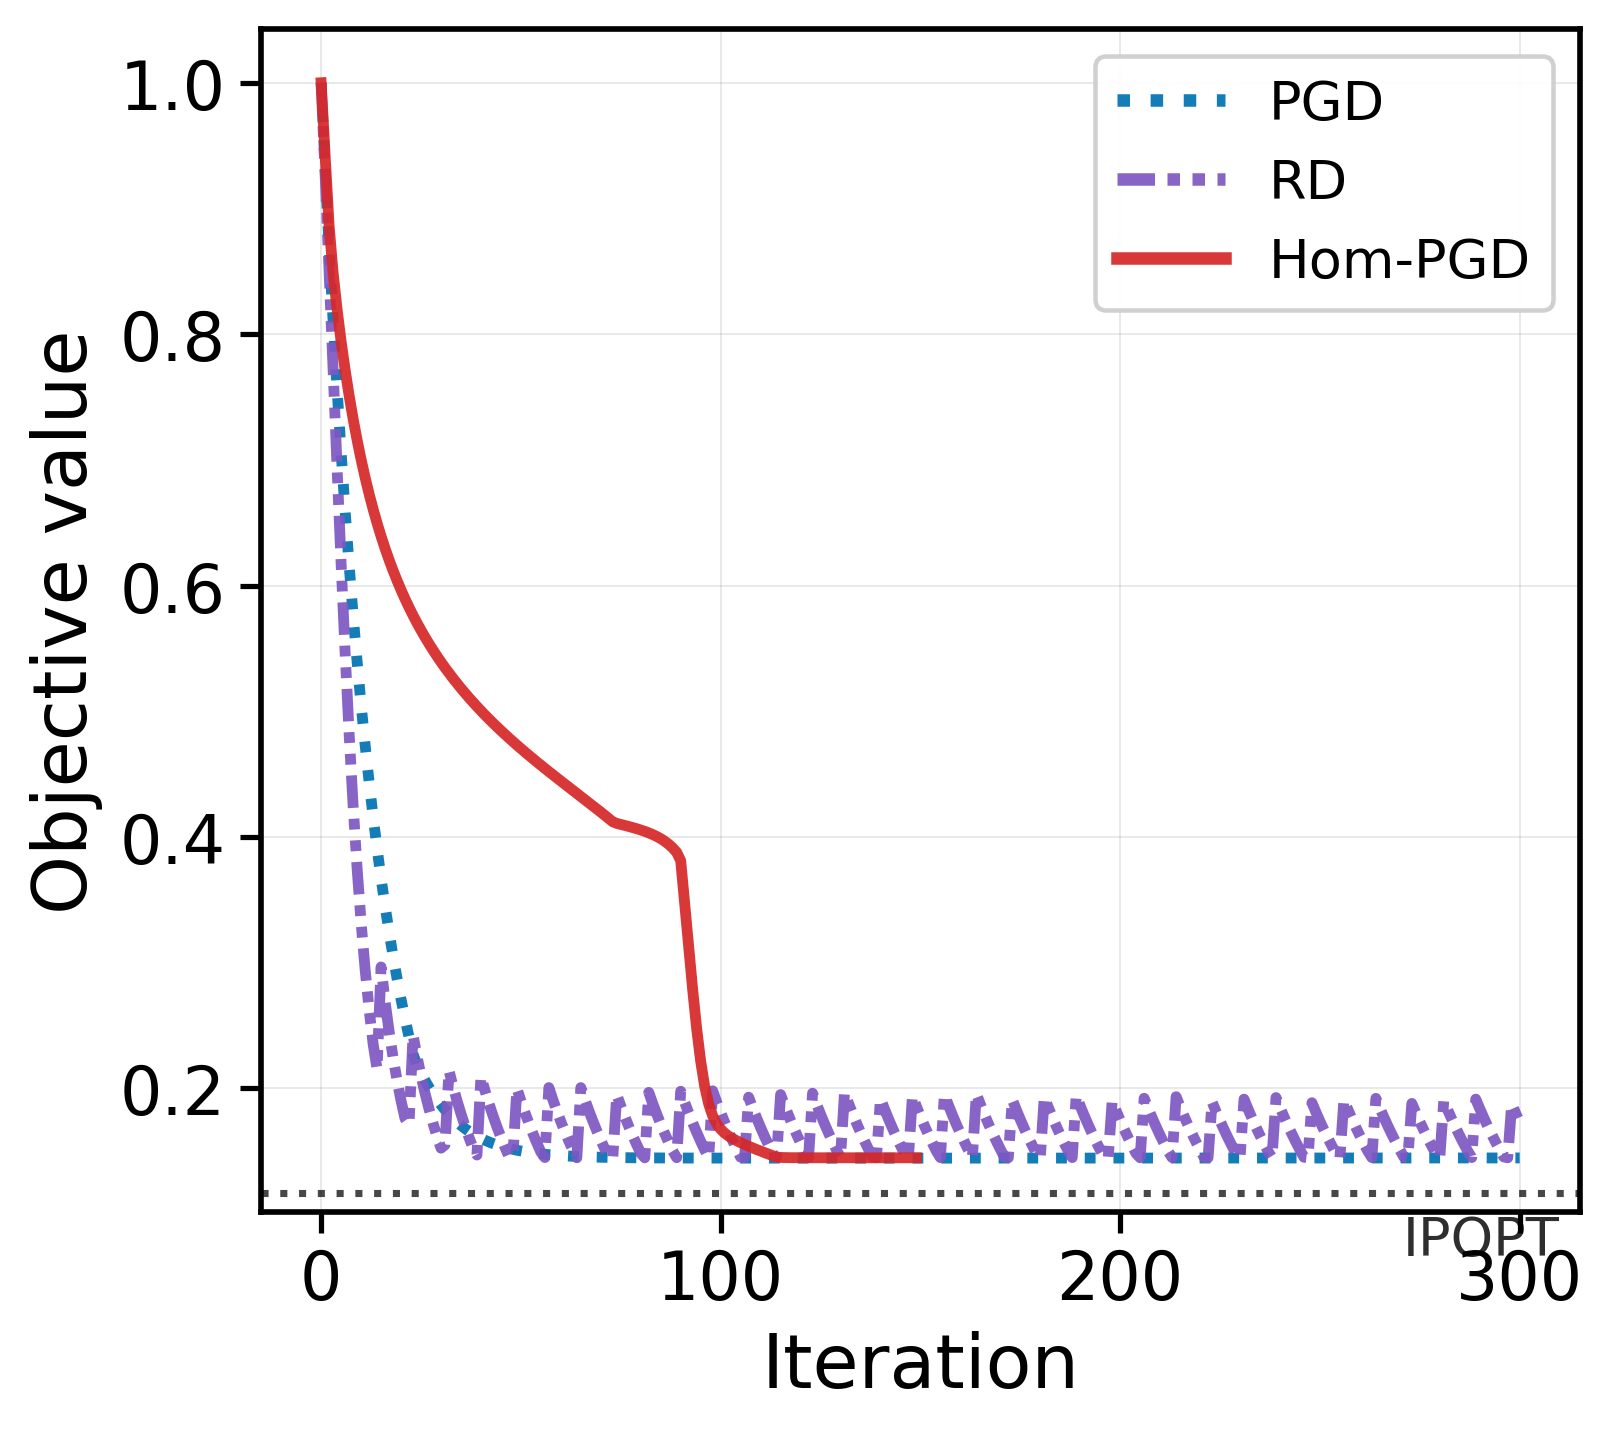

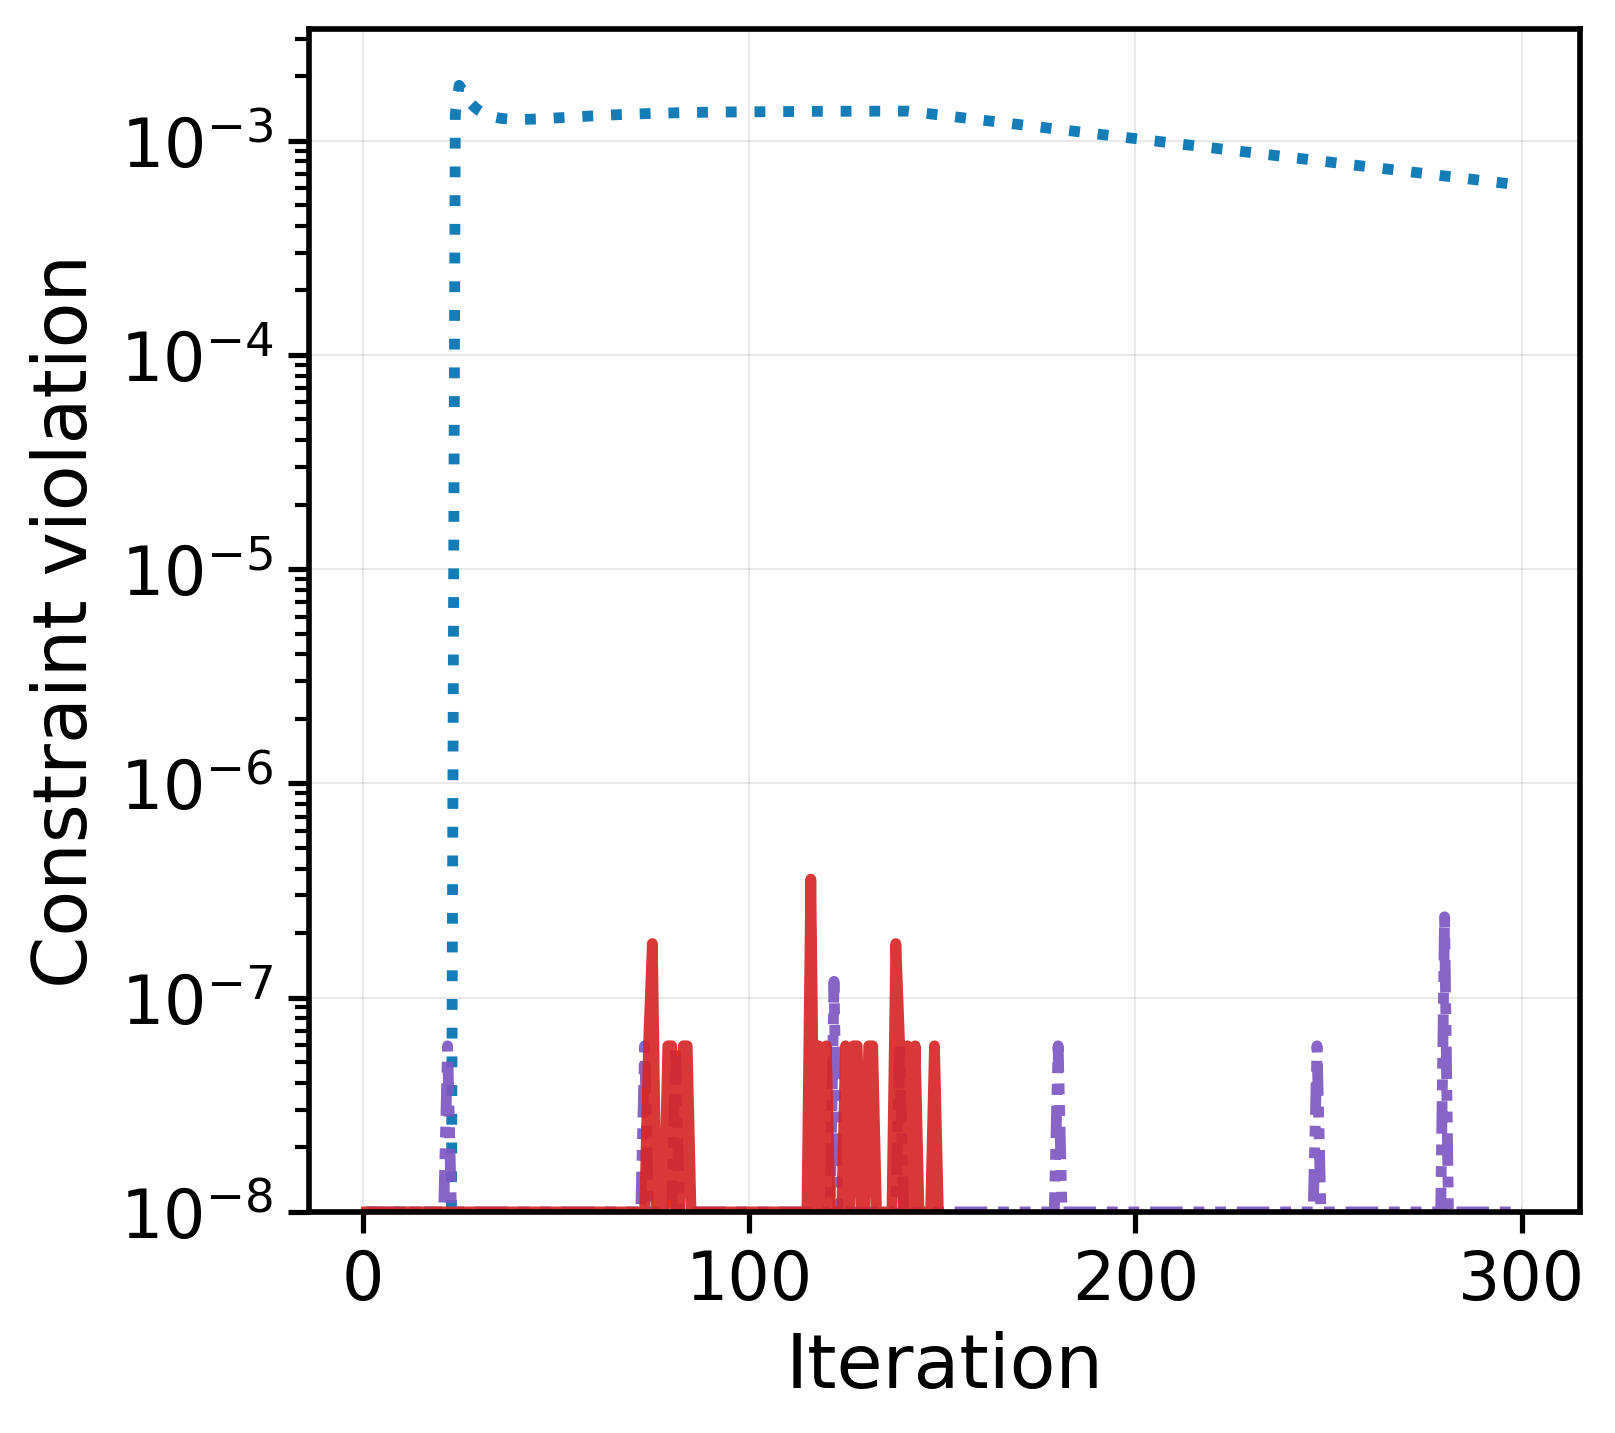

{'objective': {'iteration': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/objective_convergence_by_iter.pdf'),
  'iteration_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/objective_convergence_by_iter_logx.pdf'),
  'time': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/objective_convergence_by_time.pdf'),
  'time_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/objective_convergence_by_time_logx.pdf')},
 'violation': {'iteration': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/violation_convergence_by_iter.pdf'),
  'iteration_logx': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/violation_convergence_by_iter_logx.pdf'),
  'time': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd

In [4]:
from homopt.viz.convergence import draw_metric_convergence

objective_paths = draw_metric_convergence(
    traces,
    'objective',
    'Objective value',
    TUTORIAL_CONFIG['figure_dir'] / 'objective_convergence.pdf',
    reference_value=float(reference['objective']),
    reference_label=reference['label'],
    method_labels=TUTORIAL_CONFIG['method_labels'],
    show_variants=('iteration',),
)
violation_paths = draw_metric_convergence(
    traces,
    'full_violation',
    'Constraint violation',
    TUTORIAL_CONFIG['figure_dir'] / 'violation_convergence.pdf',
    log_y=True,
    y_min_clip=TUTORIAL_CONFIG['common_config']['convergence_threshold'],
    method_labels=TUTORIAL_CONFIG['method_labels'],
    show_legend=False,
    show_variants=('iteration',),
)
{'objective': objective_paths, 'violation': violation_paths}


## 5. Outer per-iteration time

The shared runtime plot reports the mean outer per-iteration time. Error bars are standard deviations over the explicit recorded iteration times, so timing differences are not inferred from objective curves.

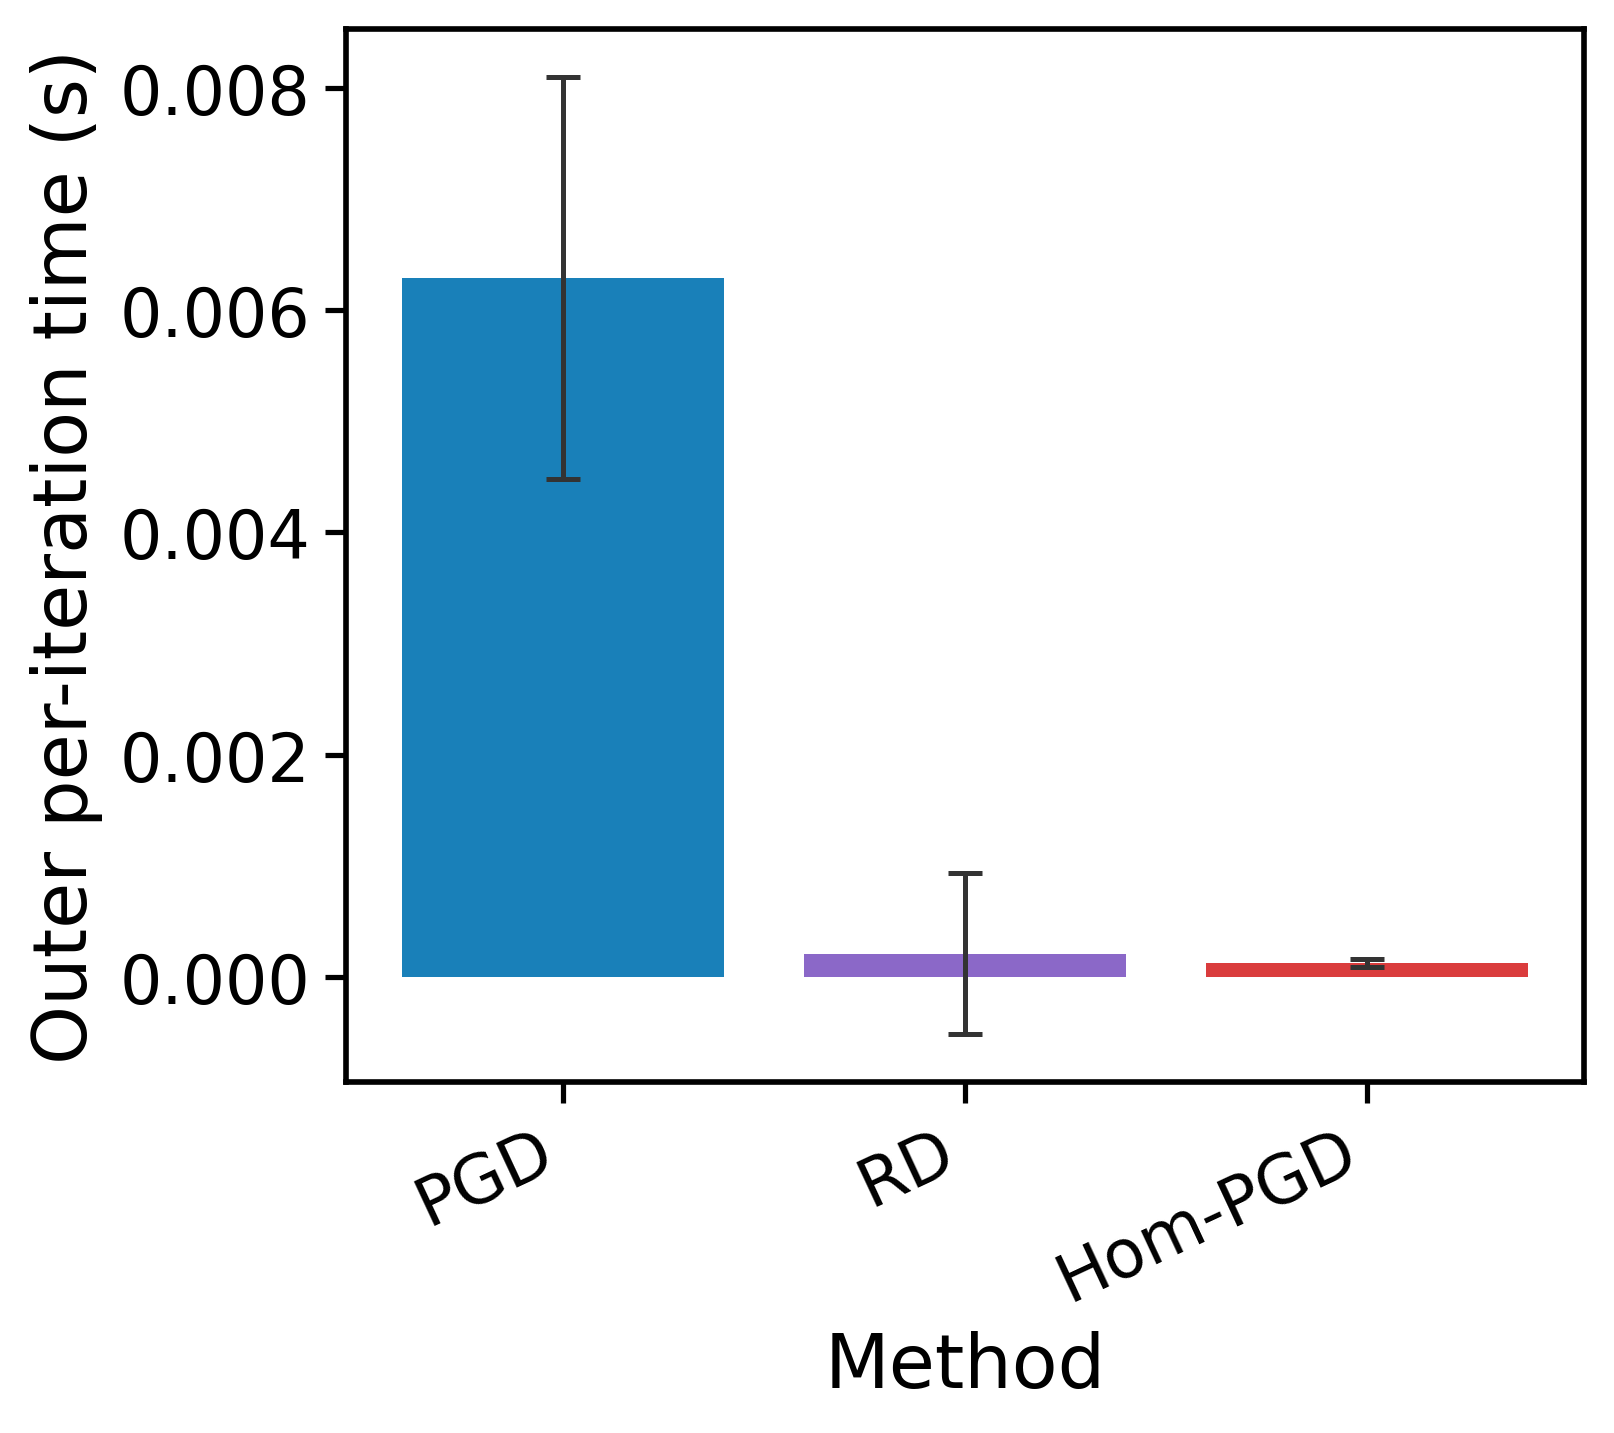

PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/04_hom_pgd_convergence/outer_per_iteration_time.pdf')

In [5]:
from homopt.viz.comparison import plot_runtime_summary

runtime_path = plot_runtime_summary(
    records,
    TUTORIAL_CONFIG['algorithms'],
    TUTORIAL_CONFIG['figure_dir'] / 'outer_per_iteration_time.pdf',
    method_labels=TUTORIAL_CONFIG['method_labels'],
    runtime_metric='outer_per_iter_time',
    show=True,
)
runtime_path


## Takeaway

A meaningful comparison shares the problem instance, initial point, reference definition, metric evaluator, iteration budget, and timing schema. The benchmark and visualization modules enforce those shared inputs; this notebook only declares the experiment and reads the resulting records.